## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt
def load_data(p): return pd.read_csv(p)
def mi_stats(df):
    vals=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    return vals.mean(),vals.median(),vals.std(),len(vals)
def raw_stats(df,col):
    vals=pd.to_numeric(df[col],errors='coerce').dropna()
    return pd.Series({'mean':f'{vals.mean():.2f}','median':f'{vals.median():.2f}',
                      'std':f'{vals.std():.2f}','min':f'{vals.min():.2f}',
                      'max':f'{vals.max():.2f}','n':len(vals)})


### Load result to data frame


In [2]:
single=load_data('single/result.csv'); multi=load_data('multi/result.csv')


# RAW MI -- All Entries


#### Overall MI Δ


Single (n=279):  ΔMI = -1.66 +/- 9.00  (median: -1.82)
Multi (n=279):  ΔMI = -1.41 +/- 7.98  (median: +0.00)


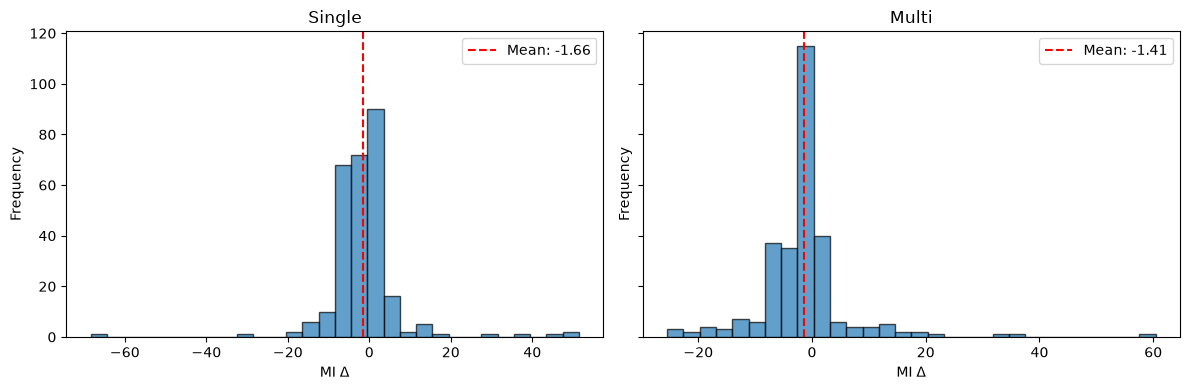

Breakdown by exit_status:
  Multi ABORT_STRATEGY (n=81):  ΔMI = +0.16 +/- 0.57
  Multi SUCCESS (n=198):  ΔMI = -2.05 +/- 9.40
  Single NO_CHANGE (n=7):  ΔMI = +0.00 +/- 0.00
  Single SUCCESS (n=272):  ΔMI = -1.70 +/- 9.11


In [3]:
for label,df in [('Single',single),('Multi',multi)]:
    m,med,s,n=mi_stats(df)
    print(f'{label} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,(label,df) in zip(axes,[('Single',single),('Multi',multi)]):
    vals=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    ax.hist(vals,bins=30,edgecolor='black',alpha=0.7)
    ax.axvline(vals.mean(),color='red',linestyle='--',label=f'Mean: {vals.mean():+.2f}')
    ax.set_title(label); ax.set_xlabel('MI Δ'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()
print('Breakdown by exit_status:')
for es,grp in pd.concat([single.assign(source='Single'),multi.assign(source='Multi')]).groupby(['source','exit_status']):
    m,med,s,n=mi_stats(grp)
    print(f'  {es[0]} {es[1]} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}')


#### Raw MI Values (Original vs Refactored)


=== Single ===
       original_mi refactored_mi mi_delta
mean         53.41         51.76    -1.66
median       54.13         52.00    -1.82
std          16.64         16.09     9.00
min           0.00          0.00   -68.39
max         107.23        107.23    51.46
n              279           279      279

=== Multi ===
       original_mi refactored_mi mi_delta
mean         53.41         52.01    -1.41
median       54.13         51.37     0.00
std          16.64         17.72     7.98
min           0.00          0.00   -25.46
max         107.23        112.59    60.41
n              279           279      279



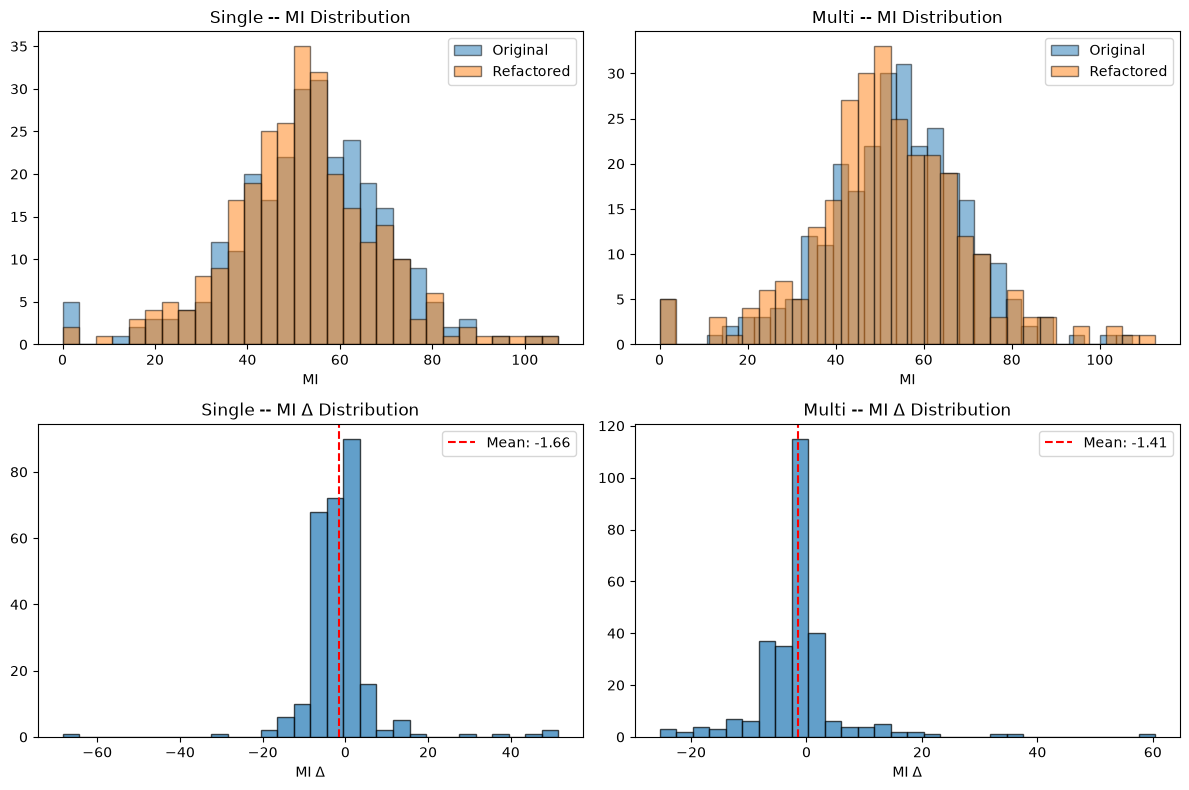

In [4]:
cols=['original_mi','refactored_mi','mi_delta']
for label,df in [('Single',single),('Multi',multi)]:
    print(f'=== {label} ===')
    print(pd.DataFrame({c:raw_stats(df,c) for c in cols})); print()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for i,(label,df) in enumerate([('Single',single),('Multi',multi)]):
    orig=pd.to_numeric(df['original_mi'],errors='coerce').dropna()
    refa=pd.to_numeric(df['refactored_mi'],errors='coerce').dropna()
    axes[0][i].hist(orig,bins=30,alpha=0.5,label='Original',edgecolor='black')
    axes[0][i].hist(refa,bins=30,alpha=0.5,label='Refactored',edgecolor='black')
    axes[0][i].set_title(f'{label} -- MI Δistribution'); axes[0][i].set_xlabel('MI'); axes[0][i].legend()
    delta=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    axes[1][i].hist(delta,bins=30,edgecolor='black',alpha=0.7)
    axes[1][i].axvline(delta.mean(),color='red',linestyle='--',label=f'Mean: {delta.mean():+.2f}')
    axes[1][i].set_title(f'{label} -- MI Δ Distribution'); axes[1][i].set_xlabel('MI Δ'); axes[1][i].legend()
plt.tight_layout(); plt.show()


#### Per-Intent MI Δ


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       2.18   1.04
DECOMPOSE_CONDITIONAL        -3.65  -4.03
EXTRACT_CONSTANT              4.62  -0.33
EXTRACT_METHOD               -5.33  -7.70
EXTRACT_VARIABLE             -1.30  -0.63
FLATTEN_CONDITIONAL          -0.46   0.13
INLINE_METHOD                -2.68  -1.04
INLINE_VARIABLE              -1.48  11.04
REMOVE_CONTROL_FLAG           3.54   3.69
RENAME_SYMBOL                 0.05  -2.13
REPLACE_LOOP_WITH_PIPELINE   -0.02   3.75
SPLIT_LOOP                   -4.24  -2.20


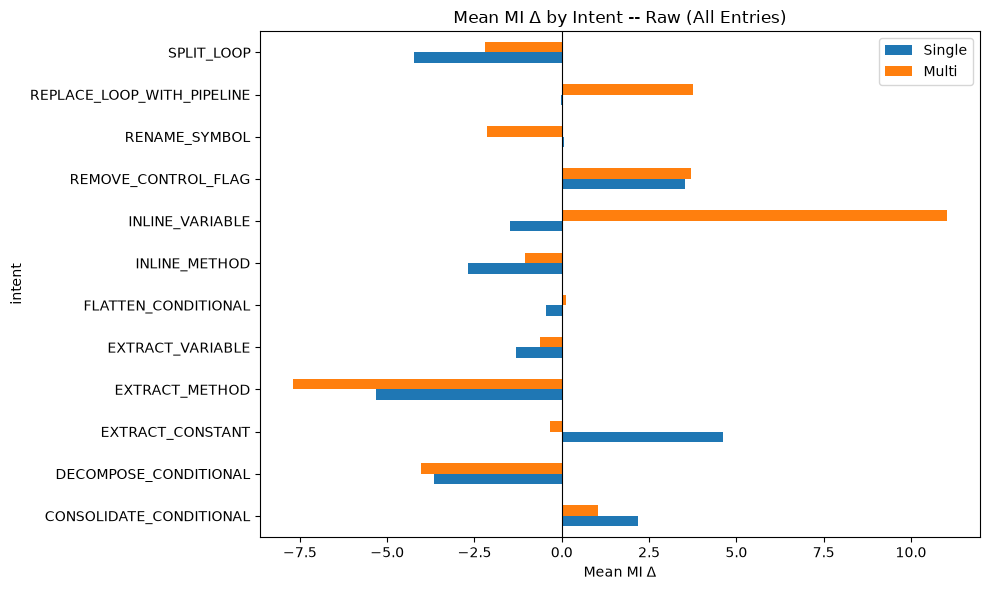

In [5]:
def intent_mi(df):
    return df.groupby('intent')['mi_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
mi_intent=pd.DataFrame({'Single':intent_mi(single),'Multi':intent_mi(multi)})
print(mi_intent)
ax=mi_intent.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Intent -- Raw (All Entries)')
ax.set_xlabel('Mean MI Δ'); plt.tight_layout(); plt.show()


#### MI Δ by Difficulty


            Single  Multi
difficulty               
Easy         -1.14  -0.70
Hard         -1.03  -1.99
Medium       -2.10  -1.51


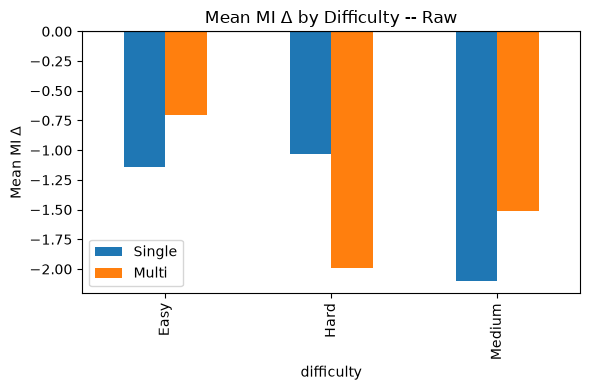

In [6]:
def diff_mi(df):
    return df.groupby('difficulty')['mi_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
mi_diff=pd.DataFrame({'Single':diff_mi(single),'Multi':diff_mi(multi)})
print(mi_diff)
ax=mi_diff.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Difficulty -- Raw'); ax.set_ylabel('Mean MI Δ')
plt.tight_layout(); plt.show()


# MI -- SUCCESS Exit Only


#### Overall MI Δ (SUCCESS Only)


Single (n=272):  ΔMI = -1.70 +/- 9.11  (median: -1.89)
Multi (n=198):  ΔMI = -2.05 +/- 9.40  (median: -2.46)


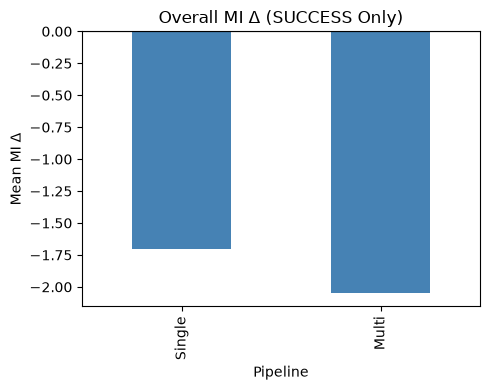

In [7]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
rows=[]
for label,df in [('Single',s_valid),('Multi',m_valid)]:
    m,med,s,n=mi_stats(df)
    print(f'{label} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
    rows.append({'Pipeline':label,'ΔMI':round(m,2)})
pd.DataFrame(rows).set_index('Pipeline').plot.bar(figsize=(5,4),color=['steelblue','coral'],legend=False)
plt.axhline(0,color='black',linewidth=0.8); plt.ylabel('Mean MI Δ'); plt.title('Overall MI Δ (SUCCESS Only)')
plt.tight_layout(); plt.show()


#### Per-Intent MI Δ (SUCCESS Only)


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       2.43   5.44
DECOMPOSE_CONDITIONAL        -3.65  -4.52
EXTRACT_CONSTANT              5.13  -0.41
EXTRACT_METHOD               -5.33  -7.70
EXTRACT_VARIABLE             -1.56  -1.66
FLATTEN_CONDITIONAL          -0.46   0.84
INLINE_METHOD                -2.68  -1.62
INLINE_VARIABLE              -1.69  11.04
REMOVE_CONTROL_FLAG           3.54   4.89
RENAME_SYMBOL                 0.05  -2.43
REPLACE_LOOP_WITH_PIPELINE   -0.02   3.75
SPLIT_LOOP                   -4.24 -11.22


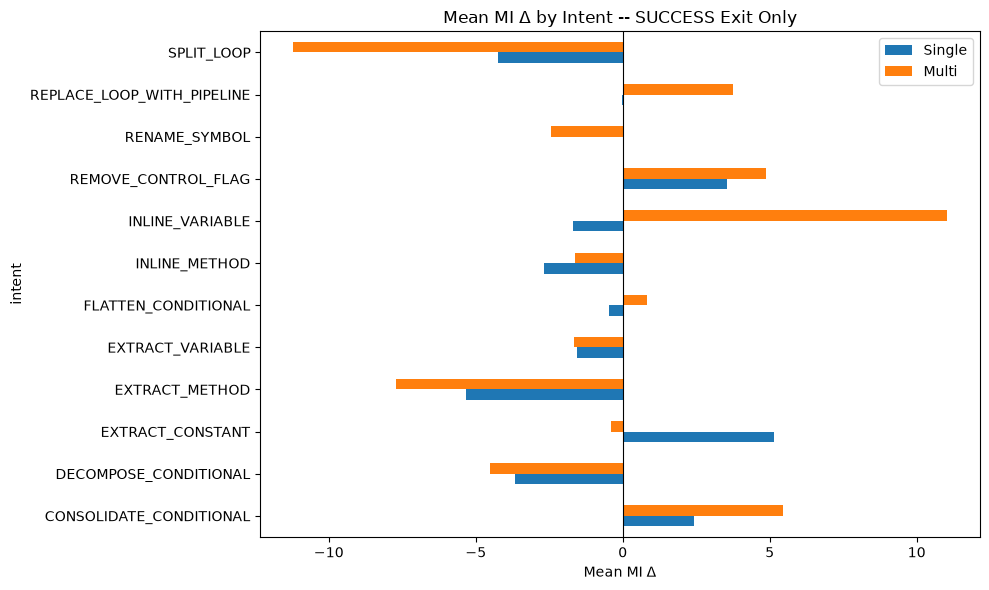

In [8]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
mi_succ=pd.DataFrame({'Single':intent_mi(s_valid),'Multi':intent_mi(m_valid)})
print(mi_succ)
ax=mi_succ.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Intent -- SUCCESS Exit Only')
ax.set_xlabel('Mean MI Δ'); plt.tight_layout(); plt.show()


#### MI Δ by Difficulty (SUCCESS Only)


            Single  Multi
difficulty               
Easy         -1.16  -0.89
Hard         -1.09  -2.89
Medium       -2.14  -2.33


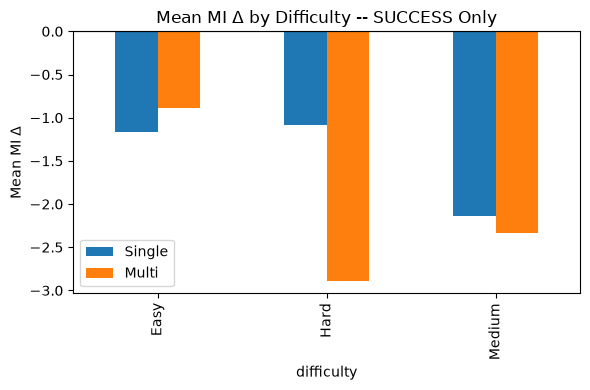

In [9]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
mi_diff_succ=pd.DataFrame({'Single':diff_mi(s_valid),'Multi':diff_mi(m_valid)})
print(mi_diff_succ)
ax=mi_diff_succ.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Difficulty -- SUCCESS Only'); ax.set_ylabel('Mean MI Δ')
plt.tight_layout(); plt.show()
